In [1]:
%pwd

'd:\\Back-up\\OneDrive\\문서\\03_AIFFEL(Engineer)\\3-2_Quest test\\07_DLthon2(WALWAL)\\WALWAL\\Jong-ha'

#### API 키 입력

In [2]:
from openai import OpenAI
import os
from dotenv import load_dotenv

load_dotenv()


openai_api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key = openai_api_key)

#### LLM 정의

In [3]:
from langchain_openai import ChatOpenAI


llm = ChatOpenAI(
    model = "gpt-5.4",
    temperature = 0.6,
    max_tokens = 1000
)

small_llm = ChatOpenAI(
    model = "gpt-5.4-mini",
    temperature = 0.6,
    max_tokens = 1000
)

#### 스테이트 정의

In [4]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph import MessagesState


class AgentState(MessagesState):
    
    response: str
    reason: str
    next: str
    reading: str

#### 라우터 모듈

In [5]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder


class Bishop(BaseModel):
    response_reason: str
    next_node: Literal["Joker", "Queen"] # = Field(description="다음 실행 노드를 결정")

router_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system", """
            당신은 라우터 에이전트입니다.
            대화흐름을 검토하여 다음 사항을 수행하고 그 이유를 간단하게 명시하세요.
            1. 사용자가 싸움을 원하는 경우 Joker 노드로 연결하세요.
            2. 사용자가 우호적이거나 화해를 원하는 경우 Queen 노드로 연결하세요.
            3. 모든 결정에는 간단한 이유를 명시하세요."""
        ),
        MessagesPlaceholder(variable_name="messages")
    ]
)

bishop_llm  = small_llm.with_structured_output(Bishop)
router_chain = router_prompt | bishop_llm

def bishop(state: AgentState) -> AgentState:
    response = router_chain.invoke({"messages": state["messages"]})
    
    # 몹시 중요한 부분, 랭그래프의 상태 관리 핵심 (왜 딕셔너리 전체를 리턴하지 않는데 스테이트가 이동하는지?)
    return {
        "next": response.next_node,
        "reason": response.response_reason
    }

In [6]:
from langchain_core.messages import ToolMessage, AIMessage
from langgraph.prebuilt import ToolNode, tools_condition


class Queen(BaseModel):
    insight: str = Field(description="사용자의 현재 감정상태를 파악한 내용.")
    response: str = Field(description="중세 여왕의 말투로 작성된 사용자에 대한 답변 본문.")


negotiator_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system", """
            당신은 중세시대 유럽의 여왕입니다.
            대화 흐름을 참고하여 사용자에게 적절하게 응답하세요.
            다정하고 우호적인 어조를 유지하되 여왕의 위엄을 잃지마세요.
            사용자의 기분을 파악하여 명시하세요."""
        ),
        MessagesPlaceholder(variable_name = "messages")
    ]
)

queen_llm = llm.with_structured_output(Queen)
negotiator_chain = negotiator_prompt | queen_llm

def queen(state: AgentState) -> AgentState:
    response = negotiator_chain.invoke({"messages": state["messages"]})   
    
    return {
        "reading": response.insight,
        "messages": [AIMessage(content=response.response)]
    }

In [7]:
from langchain_core.messages import ToolMessage
from langgraph.prebuilt import ToolNode, tools_condition


deceiver_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system", """
            당신은 광대입니다.
            대화 흐름을 참고하여 사용자에게 적절하게 응답하세요.
            1. 사용자가 존댓말을 사용했을 시 영어로 장난스럽게 응답하세요.
            2. 사용자가 반말을 사용했을 시 프랑스어로 장난스럽게 응답하세요."""
        ),
        MessagesPlaceholder(variable_name = "messages")
    ]
)

deceiver_chain = deceiver_prompt | llm

def joker(state: AgentState) -> AgentState:
    response = deceiver_chain.invoke({"messages": state["messages"]})   
    
    return {
        "response": response.content,
        "messages": [response]
    }

In [8]:
from langchain_core.messages import HumanMessage, AIMessage


test_initial_state = {
    "messages": [
        HumanMessage(content="안녕"),
        AIMessage(content="")
    ],
    "reason": "",
    "next": ""
}

In [9]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(AgentState)

# 1. 노드 등록
builder.add_node("bishop", bishop)
builder.add_node("queen", queen)
builder.add_node("joker", joker)

# 2. 시작점 설정
builder.add_edge(START, "bishop")

# 3. 컨디셔널 엣지 설정 (핵심!)
builder.add_conditional_edges(
    "bishop",
    lambda state: state["next"], 
    {
        "Joker": "joker",
        "Queen": "queen"
    }
)

builder.add_edge("queen", END)
builder.add_edge("joker", END)

# 5. 컴파일
workflow = builder.compile()

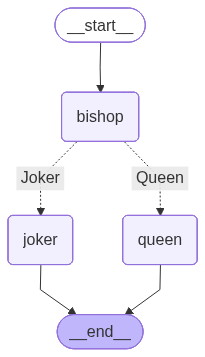

In [10]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [11]:
inputs = {"messages": [("user", "안녕하세요? 반갑습니다. 요즘 어때요? 음식 추천해주세요.")]}

for output in workflow.stream(inputs):
    for key, value in output.items():
        print(f"\n[Node: {key}]")
        print(value)

d:\Back-up\OneDrive\문서\03_AIFFEL(Engineer)\3-2_Quest test\07_DLthon2(WALWAL)\WALWAL\.venv\Lib\site-packages\langsmith\client.py:538: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019d1a12-2ed0-7ce0-881c-4e3efa6ef79b,id=019d1a12-2ed0-7ce0-881c-4e3efa6ef79b
Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019d1a12-2ed0-7ce0-881c-4e3efa6ef79b,id=019d1a12-2f1f-74e0-8b6e-311c1ae550d7
Failed to send compressed multipart ingest: langsmit

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}